# Multiple mistakes Michael

We are going to run through this notebook in the Week 2 seminar to examine  a few python basics and common mistakes. This will hopefully help you get across some well known features of python and astropy and some common problems too.

In [ ]:
## jupyter-lab 

And any comment in here will generate error messgae 

In [1]:
# Import various libraries and some specific functions. 

import numpy as np
import astropy
import photutils
import ccdproc
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from ccdproc import CCDData, combiner
from astropy import units as u

import gc
gc.enable()


### Question: You import libraries but they cannot be found? What may have happened and how can you fix it?

### <font color='blue'> Answer: </font>

In [2]:
filename = 'NGC_3766_R_00004556.fits'
#myimage = CCDData.read('filename') # Why won't this work
myimage = CCDData.read(filename, unit='adu') # Why won't this work


Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


In [3]:
myimage.header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1679 / length of data axis 1                          
NAXIS2  =                 1268 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
OBSERVER= 'Monash C14 Observer' / SBIGFITSEXT The name of the observer          
ORIGIN  = 'Monash C14'         / Description of location                        
TELESCOP= 'C14     '        

### Question: What may be happening if we get ''is not defined'' error?  What may have happened and how can you fix it?

### <font color='blue'> Answer: </font>

### Question: What have I done now? (Clue: start at the bottom of the error message and work up.)

### <font color='blue'> Answer: </font>

## Lets look at myimage

In [4]:
myimage.header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1679 / length of data axis 1                          
NAXIS2  =                 1268 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
OBSERVER= 'Monash C14 Observer' / SBIGFITSEXT The name of the observer          
ORIGIN  = 'Monash C14'         / Description of location                        
TELESCOP= 'C14     '        

In [5]:
print(myimage.header)

SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                 1679 / length of data axis 1                          NAXIS2  =                 1268 / length of data axis 2                          EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H BZERO   =                32768 / offset data range to that of unsigned short    BSCALE  =                    1 / default scaling factor                         OBSERVER= 'Monash C14 Observer' / SBIGFITSEXT The name of the observer          ORIGIN  = 'Monash C14'         / Description of location                        TELESCOP= 'C14     '           / SBIGFIT

In [6]:
myimage.data

array([[5091, 4906, 4979, ..., 4993, 4821, 4756],
       [4880, 5061, 4920, ..., 5095, 4953, 4842],
       [5216, 5059, 4991, ..., 5016, 4910, 4851],
       ...,
       [5081, 5106, 5235, ..., 5102, 4726, 4847],
       [5027, 4905, 4958, ..., 4862, 4829, 4934],
       [5038, 4874, 5185, ..., 4686, 4846, 4989]],
      shape=(1268, 1679), dtype=uint16)

### Question: what have we just printed here?

### <font color='blue'> Answer: </font>

## If statement 

In [7]:
if myimage.data[0][0]==5091:
    print("Look what I've found")

Look what I've found


In [8]:
if myimage.data[0][0]!=1234:
    print("Look what I haven't found")

Look what I haven't found


## If and in

In [9]:
if 65000 in myimage.data:
    print("Look what I've found")

In [10]:
if 'ORIGIN' in myimage.header:
    print('ORIGIN: ', myimage.header['ORIGIN'])


ORIGIN:  Monash C14


### Question: What is if and in doing?

### <font color='blue'> Answer: </font>

## For loops

If you used to them this is trivial, if not for loops are one of those conceptual problems that takes a while to grasp. Don't worry, you'll get it.

In [11]:
for name in ['Gary', 'Barry', 'The other Barry']:
    print(name)

Gary
Barry
The other Barry


In [13]:
names = ['Gary', 'Barry', 'The other Barry']
for name in names:
    print(names)

['Gary', 'Barry', 'The other Barry']
['Gary', 'Barry', 'The other Barry']
['Gary', 'Barry', 'The other Barry']


In [14]:
names = []
for name in ['Gary', 'Barry', 'The other Barry']:
    names.append(name)
print(names)

['Gary', 'Barry', 'The other Barry']


In [15]:
names = [name for name in ['Gary', 'Barry', 'The other Barry']]
print(names)

['Gary', 'Barry', 'The other Barry']


## For loops and inspecting data

In [16]:
print('Print out of data')
print(myimage.data)

print('\n\n')
print('Output of for loop')
for x in myimage.data:
    print(x)

#for y in myimage.data:
#    for x in y:
#        print(x)

Print out of data
[[5091 4906 4979 ... 4993 4821 4756]
 [4880 5061 4920 ... 5095 4953 4842]
 [5216 5059 4991 ... 5016 4910 4851]
 ...
 [5081 5106 5235 ... 5102 4726 4847]
 [5027 4905 4958 ... 4862 4829 4934]
 [5038 4874 5185 ... 4686 4846 4989]]



Output of for loop
[5091 4906 4979 ... 4993 4821 4756]
[4880 5061 4920 ... 5095 4953 4842]
[5216 5059 4991 ... 5016 4910 4851]
[4975 4972 4934 ... 4991 4983 4938]
[5119 5013 4869 ... 5118 4994 4699]
[5085 4934 5001 ... 4899 4925 4828]
[5081 4996 5038 ... 5061 4858 4747]
[4937 5014 5037 ... 5229 4856 4822]
[5061 5031 5021 ... 5010 4700 4796]
[5047 4980 5147 ... 5013 4695 4746]
[4965 4913 5047 ... 4933 4972 4939]
[5025 5038 4811 ... 5070 4933 4650]
[5043 4983 5044 ... 5088 4890 4523]
[4969 4907 5101 ... 5019 4931 4799]
[5063 5012 5050 ... 5054 4680 4685]
[5025 4999 5100 ... 4859 4997 4674]
[5081 5176 5140 ... 4901 4914 4799]
[5103 4975 5056 ... 4911 4917 4707]
[5227 5160 5251 ... 5058 4780 4781]
[5193 4969 5177 ... 4837 4876 4727]
[4982 5133 4

In [17]:
for idx, x in enumerate(myimage.data):
    if idx<10:
        print(idx, x)

print(myimage.data[5])

0 [5091 4906 4979 ... 4993 4821 4756]
1 [4880 5061 4920 ... 5095 4953 4842]
2 [5216 5059 4991 ... 5016 4910 4851]
3 [4975 4972 4934 ... 4991 4983 4938]
4 [5119 5013 4869 ... 5118 4994 4699]
5 [5085 4934 5001 ... 4899 4925 4828]
6 [5081 4996 5038 ... 5061 4858 4747]
7 [4937 5014 5037 ... 5229 4856 4822]
8 [5061 5031 5021 ... 5010 4700 4796]
9 [5047 4980 5147 ... 5013 4695 4746]
[5085 4934 5001 ... 4899 4925 4828]


In [20]:
# Here is a while loop - how does it compare to what is above?

idx = 0 
while idx<10:
    print(idx, myimage.data[idx])
    idx=idx+1

print('myimage.data[5]')

0 [5091 4906 4979 ... 4993 4821 4756]
1 [4880 5061 4920 ... 5095 4953 4842]
2 [5216 5059 4991 ... 5016 4910 4851]
3 [4975 4972 4934 ... 4991 4983 4938]
4 [5119 5013 4869 ... 5118 4994 4699]
5 [5085 4934 5001 ... 4899 4925 4828]
6 [5081 4996 5038 ... 5061 4858 4747]
7 [4937 5014 5037 ... 5229 4856 4822]
8 [5061 5031 5021 ... 5010 4700 4796]
9 [5047 4980 5147 ... 5013 4695 4746]
myimage.data[5]


# Plotting images 

[[5091 4906 4979 ... 4993 4821 4756]
 [4880 5061 4920 ... 5095 4953 4842]
 [5216 5059 4991 ... 5016 4910 4851]
 ...
 [5081 5106 5235 ... 5102 4726 4847]
 [5027 4905 4958 ... 4862 4829 4934]
 [5038 4874 5185 ... 4686 4846 4989]] adu


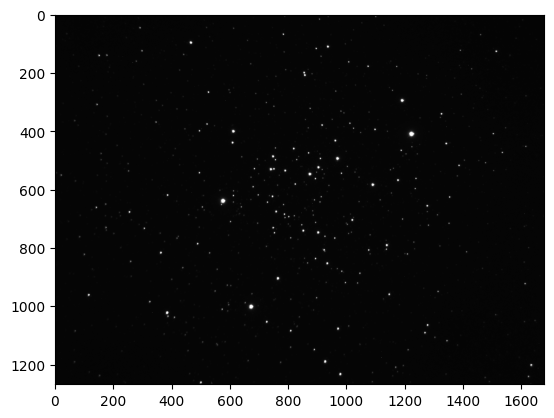

In [21]:
# Lets plot the image 

print(myimage)
plt.imshow(myimage.data, cmap='gray')


## Question: How do we add labels and axes?

### <font color='blue'> Answer: </font>

Text(0, 0.5, 'Y')

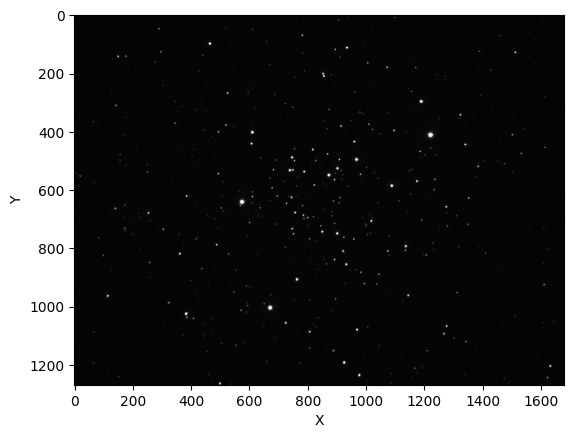

In [34]:
plt.imshow(myimage.data, cmap='gray')
plt.xlabel('X')
plt.ylabel('Y')

## Question: How can we add more detail?

### <font color='blue'> Answer: </font>

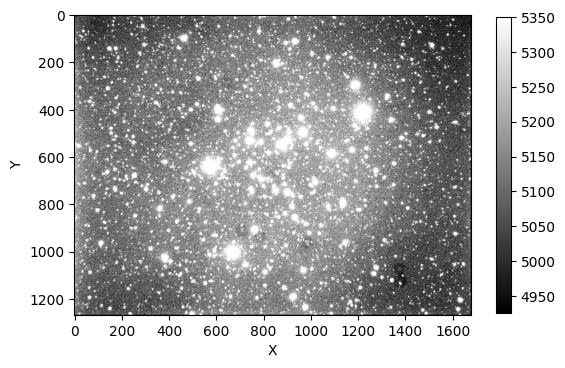

In [46]:
vmin=np.percentile(myimage.data,4)
vmax=np.percentile(myimage.data,90)

plt.imshow(myimage.data, cmap='gray', vmin=vmin, vmax=vmax)
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(shrink=0.8)

## Lets try another image 

In [56]:
filename = 'Dark_3600.000secs00002950.fits'
darkimage = CCDData.read(filename, unit="adu")
darkimage.header

Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1679 / length of data axis 1                          
NAXIS2  =                 1268 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
OBSERVER= 'Monash C14 Observer' / SBIGFITSEXT The name of the observer          
ORIGIN  = 'Monash C14'         / Description of location                        
TELESCOP= 'C14     '        

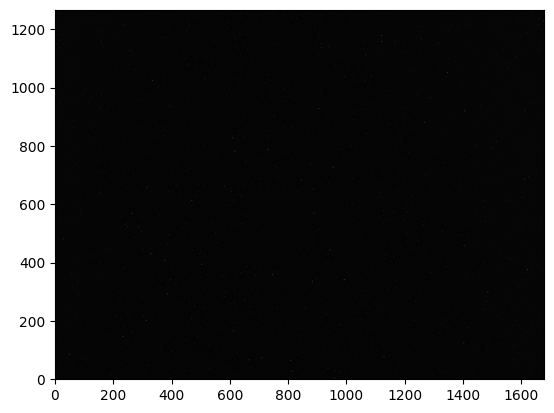

In [43]:
plt.imshow(darkimage.data, origin='lower', cmap='gray')


## Question: How can improve we improve the detail visible?


In [29]:
## Lets modify this image and display it

2245.0 2873.0


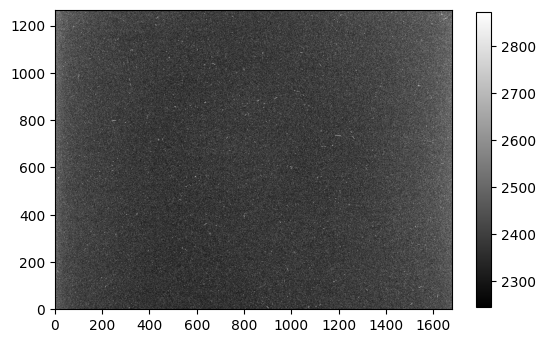

In [60]:
vmin = np.nanpercentile(darkimage.data,1)
vmax = np.nanpercentile(darkimage.data,99)
plt.imshow(darkimage.data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.8)
print(vmin, vmax)

## Question: What has changed in this image? How can we see or measure such a change?

### <font color='blue'> Answer: </font>

## Question: Can we run the same cell more than once? If so what happens? 

### <font color='blue'> Answer: </font>

## Question: Does it matter if we run cells more than once?

### <font color='blue'> Answer: </font>

## Lets load some images 

In [64]:
filename = 'Bias_00005290.fits'
biasimage = CCDData.read(filename, unit="adu")
filename = 'Dark_3600.000secs00002950.fits'
darkimage = CCDData.read(filename, unit="adu")
filename = 'NGC_3766_R_00004556.fits'
myimage = CCDData.read(filename, unit="adu")

## And modify their values 

In [67]:
print('Before')
print('Myimage median:', np.nanmedian(myimage.data))
print('Biasimage median:', np.nanmedian(biasimage.data))

tempimage = myimage.copy()
tempimage.data = tempimage.data - biasimage.data

print('\n')
print('After')
print('Myimage median:', np.nanmedian(myimage.data))
print('Biasimage median:', np.nanmedian(biasimage.data))
print('Tempimage median:', np.nanmedian(tempimage.data))


Before
Myimage median: 5144.0
Biasimage median: 2021.0


After
Myimage median: 5144.0
Biasimage median: 2021.0
Tempimage median: 3122.0


## Question: How and why have the values of myimage and tempimage changed or not changed?

### <font color='blue'> Answer: </font>

## Let's load some images and modify their values again 

In [69]:
filename = 'Bias_00005290.fits'
biasimage = CCDData.read(filename, unit="adu")
filename = 'Dark_3600.000secs00002950.fits'
darkimage = CCDData.read(filename, unit="adu")
filename = 'NGC_3766_R_00004556.fits'
myimage = CCDData.read(filename, unit="adu")

print('Before')
print('Myimage median:', np.nanmedian(myimage.data))
print('Biasimage median:', np.nanmedian(biasimage.data))

tempimage = myimage.copy()
tempimage.data = tempimage.data - biasimage.data

print('\n')
print('After')
print('Myimage median:', np.nanmedian(myimage.data))
print('Biasimage median:', np.nanmedian(biasimage.data))
print('Tempimage median:', np.nanmedian(tempimage.data))


Before
Myimage median: 5144.0
Biasimage median: 2021.0


After
Myimage median: 5144.0
Biasimage median: 2021.0
Tempimage median: 3122.0


## Question: How and why have the values of myimage and tempimage changed or not changed?

### <font color='blue'> Answer: </font>